In [ ]:
%matplotlib inline
# Importing the course packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the course datasets
country_data = pd.read_csv('../datasets/countries-of-the-world.csv', decimal=",")
mpg = pd.read_csv('../datasets/mpg.csv')
student_data = pd.read_csv('../datasets/student-alcohol-consumption.csv', index_col=0)
survey = pd.read_csv('../datasets/young-people-survey-responses.csv', index_col=0)

# Relational Plots 

- Relational plots describe the relationship between two quantitative variables
- Ex: Height vs. Weight (do taller people weigh more?) Absences vs. Grade (relation between attendance and performance)
- Can use hue parameter to visualize when relation is different between subgroups
- Alternatively, can use a separate plot per subgroup
    - Use seaborn function "relplot()"
    - Relplot allows subplots in a single figure

In [2]:
tips = sns.load_dataset('tips')
# Demonstrate the use of relplot() with the tips dataset
sns.relplot(x='total_bill', y='tip', data=tips) # Note that default is scatter, but can specify using kind=... for different types of plots
plt.show()

NameError: name 'sns' is not defined

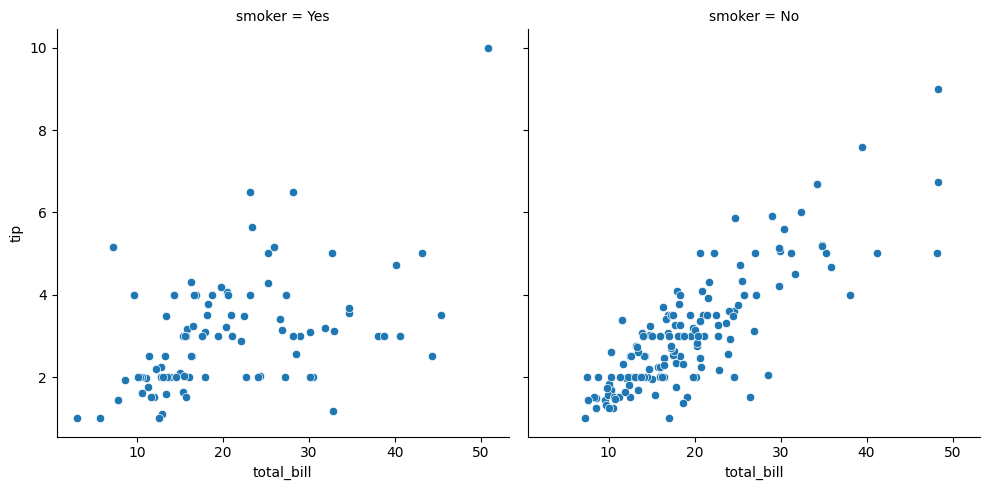

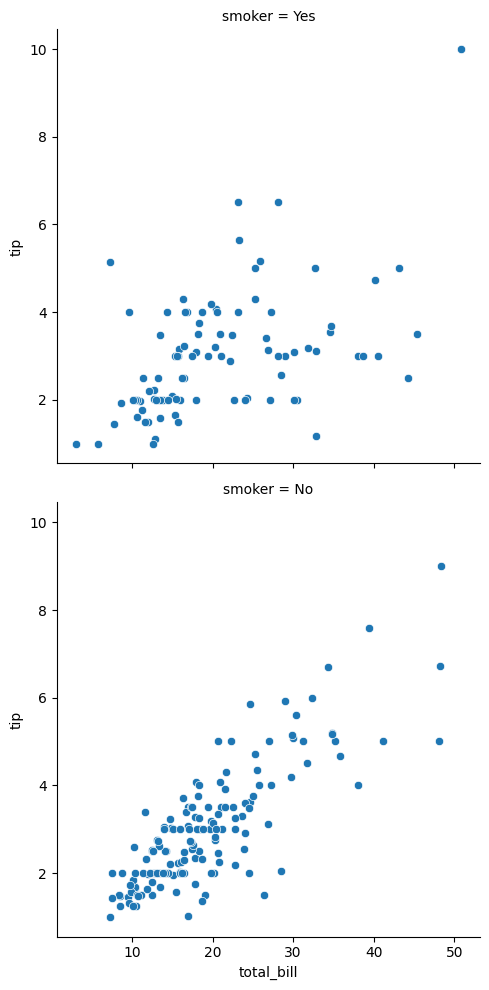

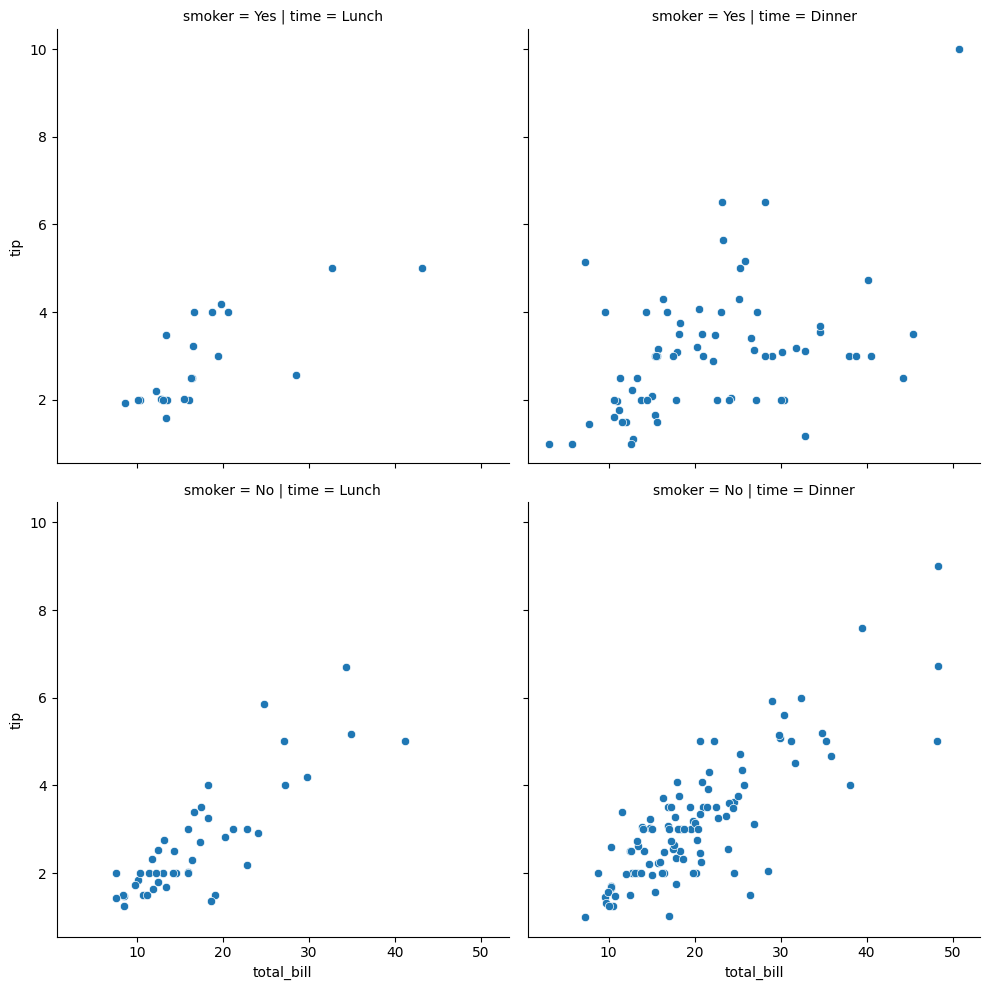

In [ ]:
# Create Subplots in columns with col=... argument
sns.relplot(x='total_bill', y='tip', data=tips, col='smoker') # smoker is a categorical variable, so it creates two subplots for each category
plt.show()

# Can use row=... to create subplots in rows instead of columns
sns.relplot(x='total_bill', y='tip', data=tips, row='smoker')
plt.show()

# Can use both row=... and col=... to create a grid of subplots
sns.relplot(x='total_bill', y='tip', data=tips, row='smoker', col='time') # time is also a categorical variable, so it creates a grid of subplots for each combination of smoker and time
plt.show()

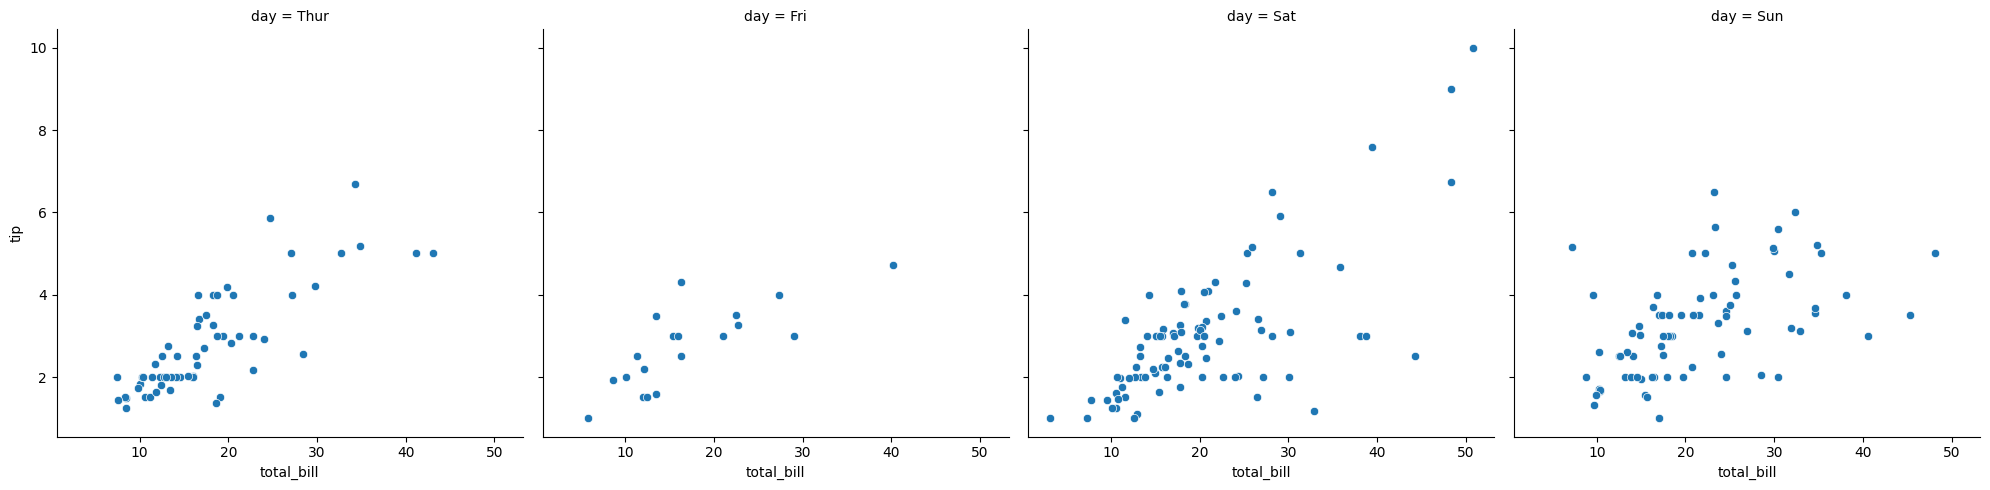

In [ ]:
# Subgroups for days of the week
sns.relplot(x='total_bill', y='tip', data=tips, col='day') # day is a categorical variable, so it creates subplots for each day of the week
plt.show()

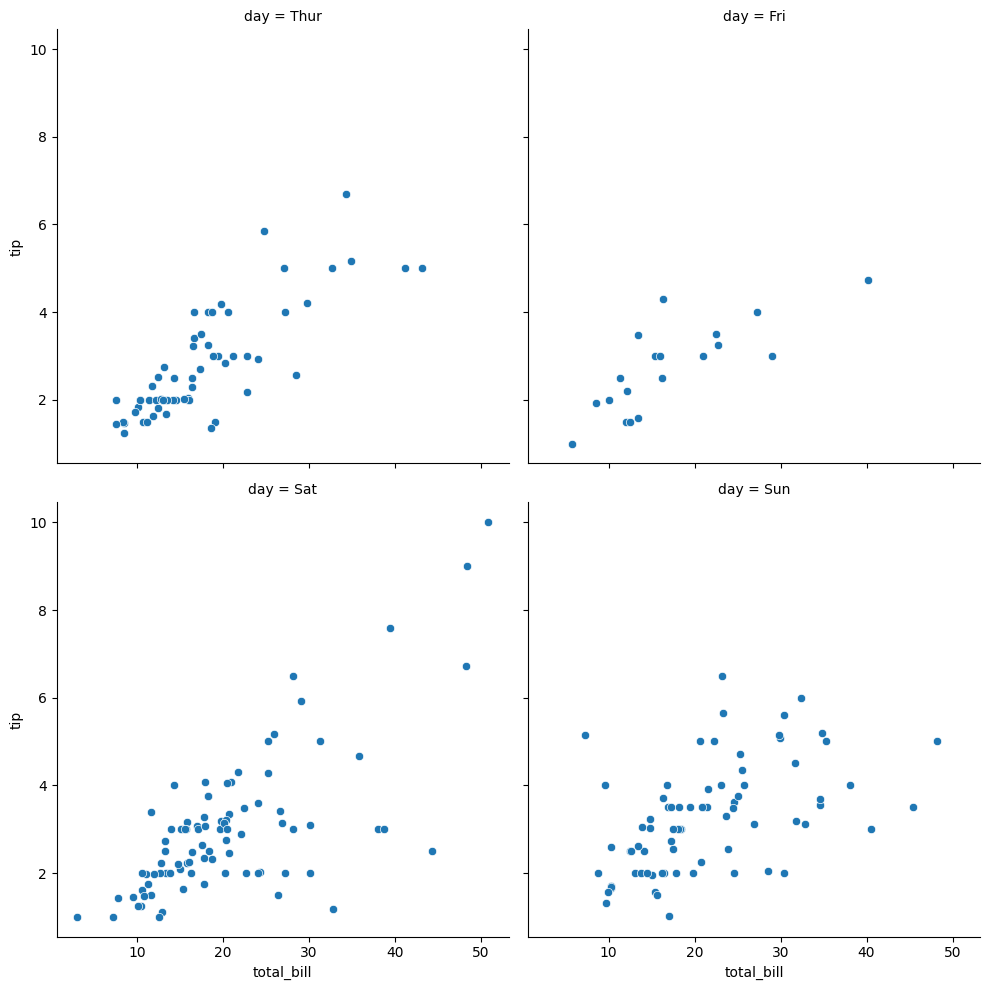

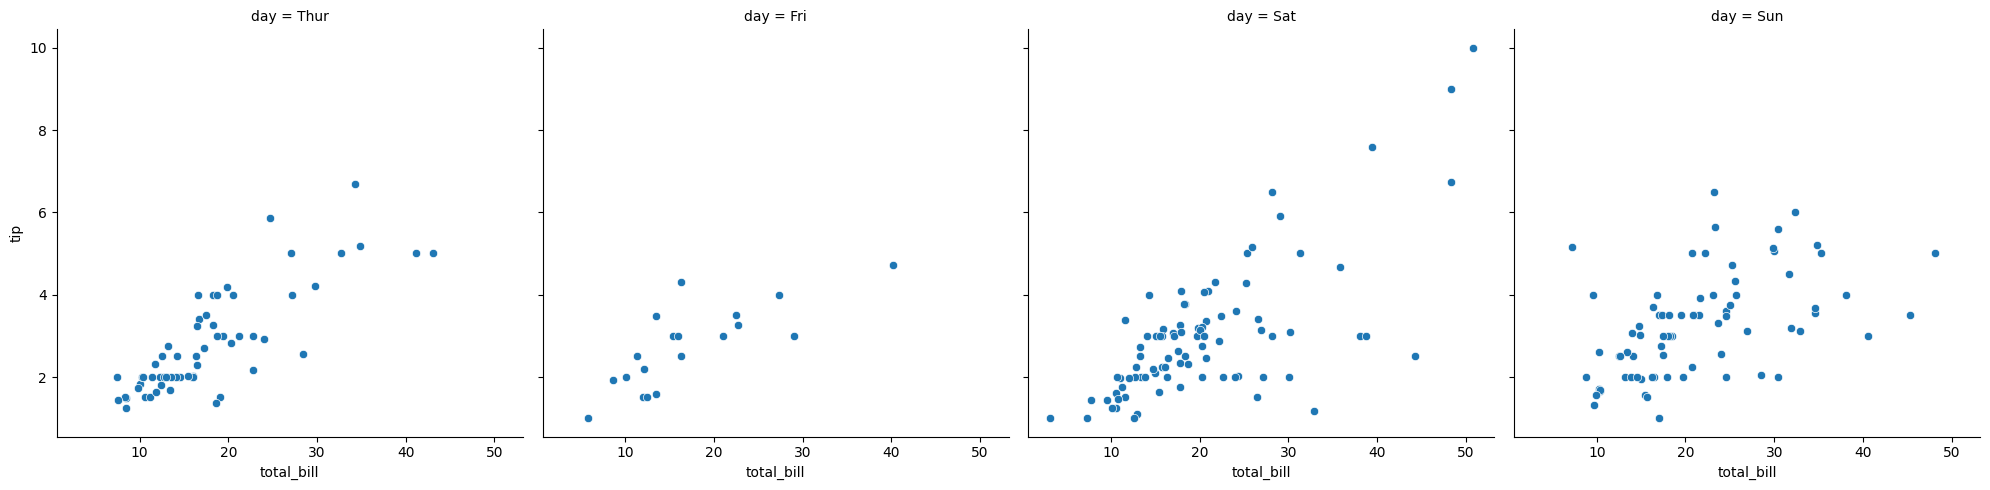

In [ ]:
# Wrapping columns -> Use the col_wrap=... argument to specify the number of columns to wrap the subplots into
sns.relplot(x='total_bill', y='tip', data=tips, col='day', col_wrap=2) # This will wrap the subplots into 2 columns, so it will create 3 rows of subplots for each day of the week
plt.show()

# Use col_order=... to specify the order of the subplots when using col=... or row=...
sns.relplot(x='total_bill', y='tip', data=tips, col='day', col_order=['Thur', 'Fri', 'Sat', 'Sun']) # This will specify the order of the subplots for each day of the week
plt.show()

# Customizing scatter plots

In [17]:
# Using tips dataset for the rest of the exercises
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


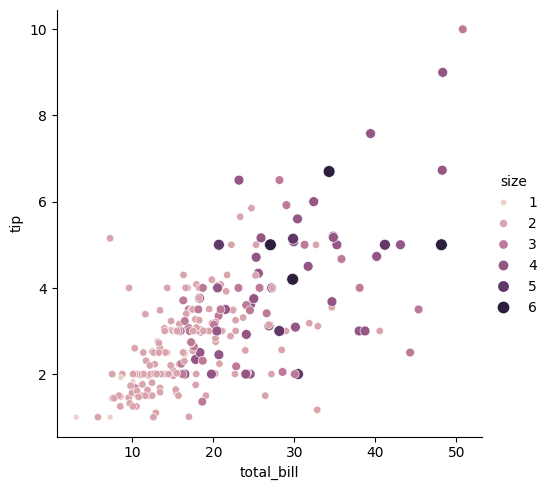

In [19]:
# Subgroups with point size and hue
sns.relplot(x='total_bill', y='tip', data=tips, size='size', hue='size') # size is a quantitative variable, so it will use the size of the points to represent the size of the group
plt.show()

- Lesson doesn't use these words, but the point is that size should be used for *ordinal* variables
- Using hue and size together makes the points easier to distinguish

## Subgroups with point style
- If "style = 'var' " for a variable name, then the style will vary based on that variable. This allows... at least 5 dimensions to be visualized?!

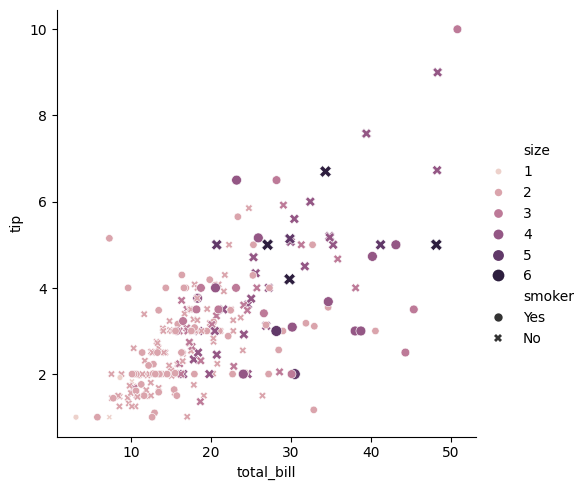

In [21]:
# Creating a five dimensional plot with relplot()
sns.relplot(x='total_bill', y='tip', data=tips, size='size', hue='size', style='smoker') # style is a categorical variable, so it will use different markers to represent the smoker and non-smoker groups
plt.show()

## Use transparency too, because why not?

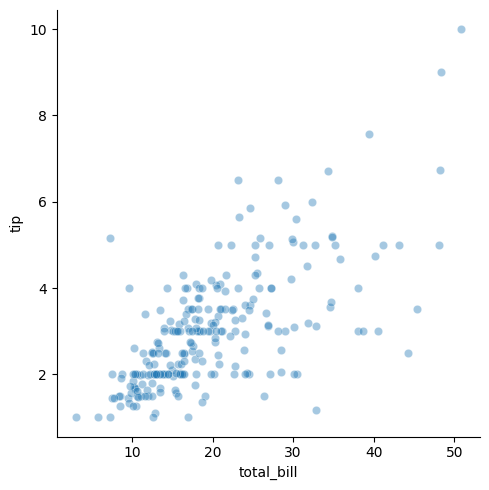

In [26]:
# Note, it looks like alpha cannot be set to a variable in relplot(), but it can be set to a constant value to adjust the transparency of the points
sns.relplot(x='total_bill', y='tip', data=tips, alpha=0.4)
plt.show()

# Line Plots
- Not sure why I bother writing this down, but...
- Use scatter when visualizing individual observations, use line when visualizing change over time
- Note: DataCamp doesn't say what dataset is used here, so I'm using https://www.airqualityontario.com/history/index.php

In [5]:
air_data_raw = pd.read_csv("../datasets/peterborough_air_quality.csv", index_col=2, parse_dates=True).drop(columns=['Station ID','Pollutant','Unnamed: 27'])

# Missing values are represented as 9999 or -999, so replace them with NaN
air_data_raw = air_data_raw.replace([9999, -999], np.nan)

# Columns for each date represent hourly readings
# Create new dataframe for daily averages by averaging hourly readings
air_data = air_data_raw.copy()
air_data["mean"] = air_data_raw.mean(axis=1)
air_data = air_data[["mean"]].dropna().reset_index() # Drop rows with missing values and reset index to have a clean dataframe with date and mean columns
air_data.head()

,Date,mean
0,2025-01-01,1.370833
1,2025-01-02,1.562500
2,2025-01-03,1.654167
3,2025-01-04,1.537500
4,2025-01-05,1.700000


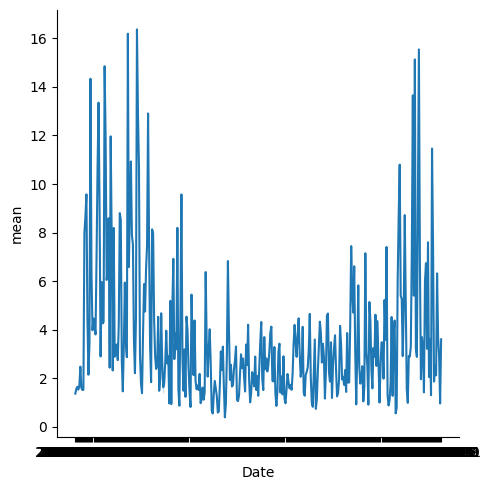

In [7]:
sns.relplot(x='Date', y='mean', data=air_data, kind='line') # This will create a line plot of the mean air quality over time
plt.show()

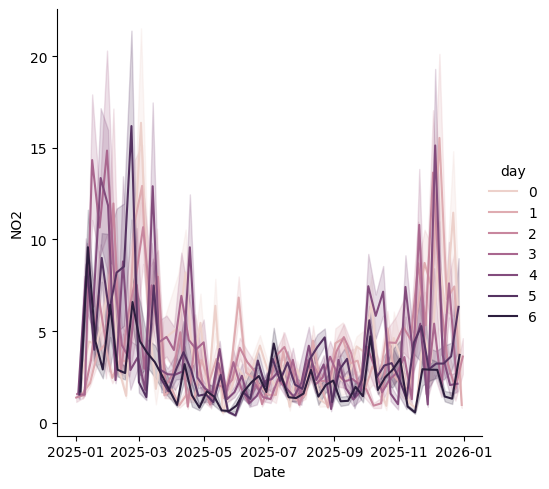

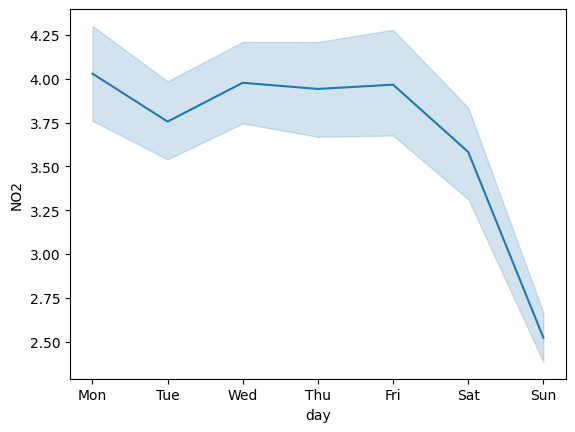

In [18]:
# Melt the original air_data dataframe to create a long format dataframe for plotting
air_data_long = air_data_raw.reset_index().melt(id_vars='Date', var_name='Hour', value_name='NO2').dropna() # This will create a long format dataframe with columns Date, Hour, and NO2
air_data_long.head()

# Convert the Date column to datetime format if it is not already in that format
air_data_long['Date'] = pd.to_datetime(air_data_long['Date'])
# Add a quantitative day of the week column to the air_data dataframe for the next exercise
air_data_long['day'] = air_data_long['Date'].dt.dayofweek # This will create a new column called 'day' that contains the day of the week as an integer (0=Monday, 1=Tuesday, ..., 6=Sunday)
air_data_long.head()

# Create a line plot of NO2 levels over time with a separate line for each day of the week
sns.relplot(x='Date', y='NO2', data=air_data_long, kind='line', hue='day') # This will create a line plot of NO2 levels over time with a separate line for each day of the week, colored by the day of the week
plt.show()

# Construct lineplot showing average NO2 level for each day of the week
sns.lineplot(x='day', y='NO2', data=air_data_long) # This will create a line plot of the average NO2 levels for each day of the week
labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.xticks(ticks=range(7), labels=labels) # This will set the x-axis ticks to be the integers from 0 to 6 and the labels to be the corresponding day of the week
plt.show()